In [106]:
# Now need to visualize the data and do some EDA

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as stattools

df = pd.read_csv('data/processed/merged_data.csv', parse_dates=["date"], index_col="date")

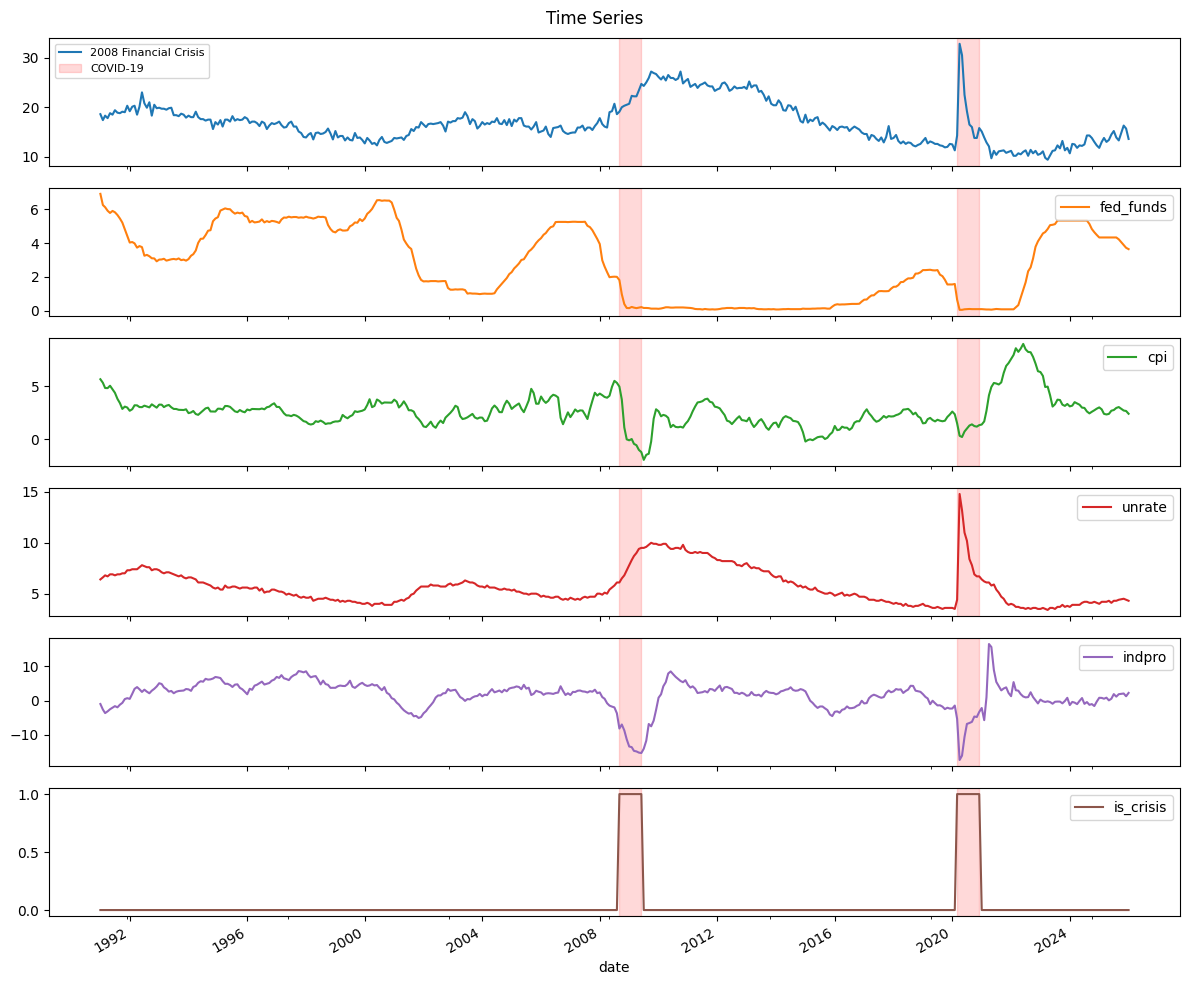

In [107]:
# 1. Time series plot
axes = df.plot(subplots=True, figsize=(12, 10), title="Time Series")

crisis_periods = [
    ("2008-09-01", "2009-06-01", "2008 Financial Crisis"),
    ("2020-03-01", "2020-12-01", "COVID-19"),
]

for ax in axes:
    for start, end, label in crisis_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='red', alpha=0.15, label=label)

axes[0].legend(["2008 Financial Crisis", "COVID-19"], fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


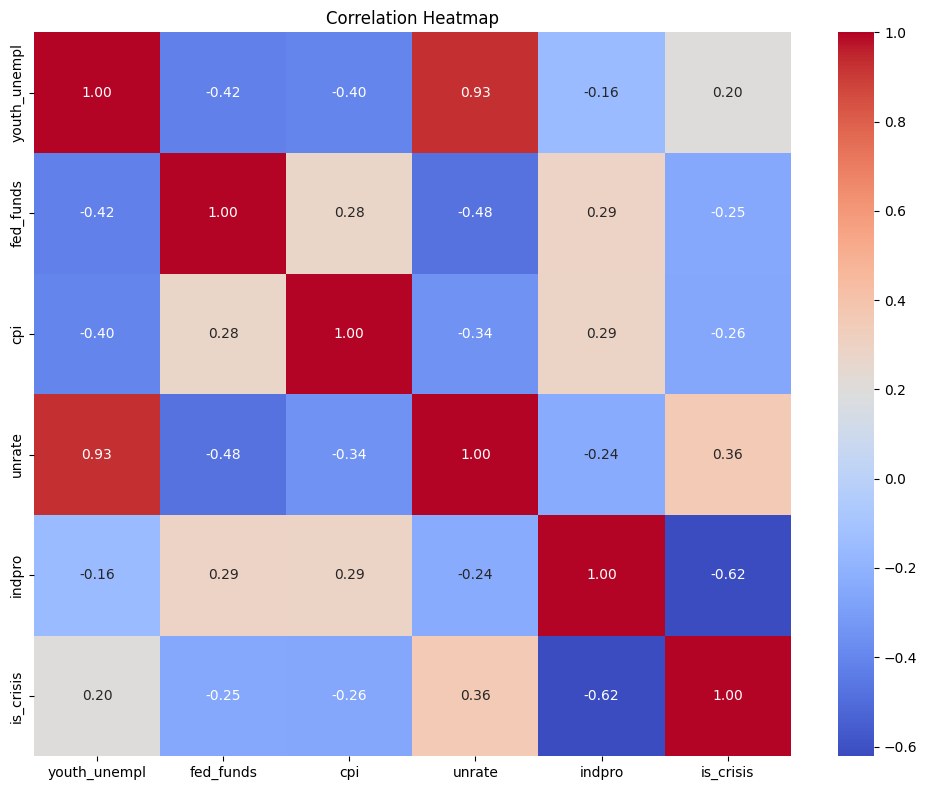

In [108]:
# 2. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

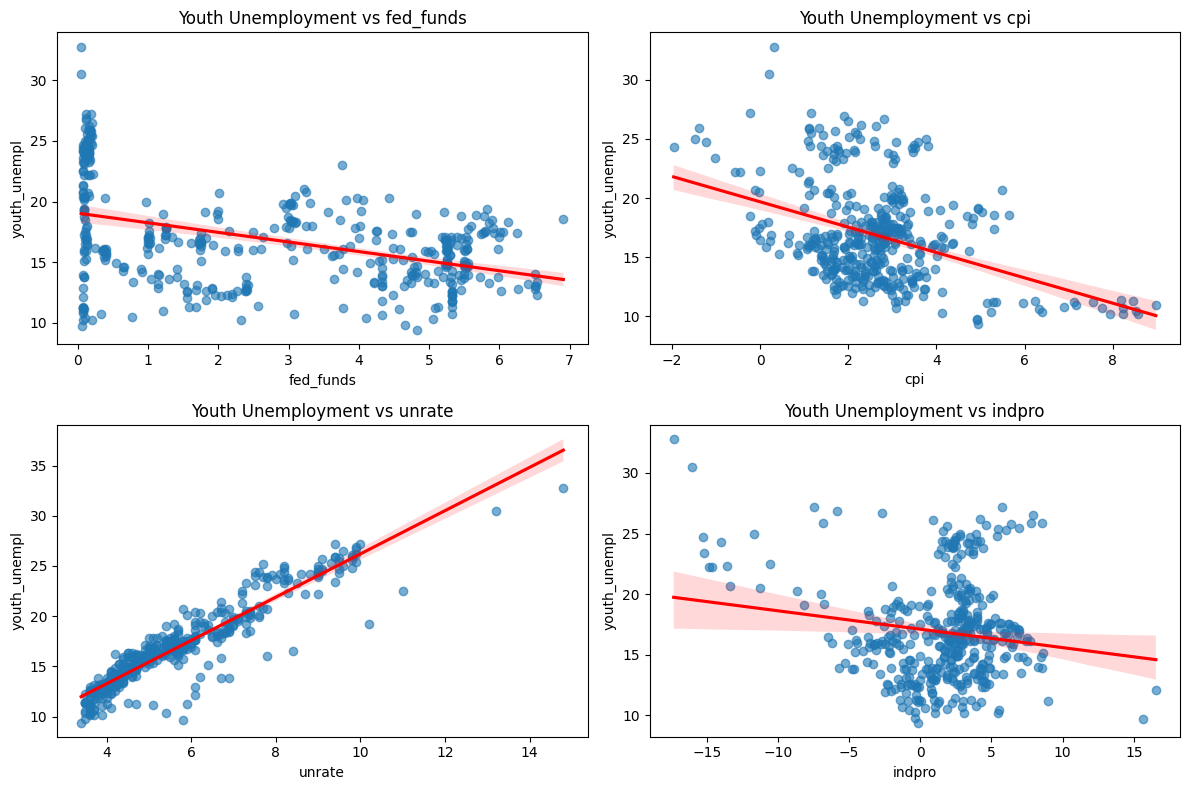

In [109]:
# 3. Scatter Plot
X_cols = ["fed_funds", "cpi", "unrate", "indpro"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), X_cols):
    sns.regplot(data=df, x=col, y="youth_unempl", ax=ax
                , scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    ax.set_title(f"Youth Unemployment vs {col}")
plt.tight_layout()
plt.show()

In [110]:
# 4. ADF Test
print("\n=== ADF TEST (p-value < 0.05 means stationary) ===")

for col in df.columns:
    result = stattools.adfuller(df[col].dropna())
    status = "Satisfies" if result[1] < 0.05 else "Does not satisfy"
    print(f"{col:<15}: p-value = {result[1]} - {status}")


=== ADF TEST (p-value < 0.05 means stationary) ===
youth_unempl   : p-value = 0.3552366190301147 - Does not satisfy
fed_funds      : p-value = 0.022060518911369325 - Satisfies
cpi            : p-value = 0.005258302317726712 - Satisfies
unrate         : p-value = 0.033723487182324687 - Satisfies
indpro         : p-value = 0.008241102991176051 - Satisfies
is_crisis      : p-value = 0.0020155402715418724 - Satisfies


In [111]:
# 5. Zivot-Andrews Test for youth_unempl
# ADF may fail due to structural breaks (2008 crisis, 2020 COVID), not true unit root
# Zivot-Andrews accounts for one structural break endogenously
from statsmodels.tsa.stattools import zivot_andrews

print("\n=== Zivot-Andrews TEST (accounts for structural break) ===")
za_result = zivot_andrews(df["youth_unempl"].dropna(), regression="ct")
t_stat = za_result[0]
p_value = za_result[1]
cv_1pct = za_result[2]["1%"]
cv_5pct = za_result[2]["5%"]
break_idx = za_result[4]
break_date = df["youth_unempl"].dropna().index[break_idx]

print(f"t-stat        : {t_stat:.4f}")
print(f"p-value       : {p_value:.4f}")
print(f"Critical (1%) : {cv_1pct:.4f}")
print(f"Critical (5%) : {cv_5pct:.4f}")
print(f"Break date    : {break_date.strftime('%Y-%m')}")
status = "Stationary (reject unit root)" if t_stat < cv_5pct else "Non-stationary"
print(f"Result        : {status}")



=== Zivot-Andrews TEST (accounts for structural break) ===
t-stat        : -3.9935
p-value       : 0.5078
Critical (1%) : -5.5756
Critical (5%) : -5.0733
Break date    : 2008-04
Result        : Non-stationary


### Why First difference `youth_unempl`?

ADF Failed -> Suspected structural breaks either 2008 or 2020 (not true unit root)


Zivot-Andrews with `ct` found break at 2008-04 [for `c` shows 2014-04 as break date] (covered by `is_crisis` dummy vairable), but still Non-Stationary (t-stat = -3.99, p-value 0.51)

-> `is_crisis` handles level jumps, but a stochastic trend remains. 

So, We need diff

In [112]:
df_diff = pd.read_csv('data/processed/merged_data_diff.csv', parse_dates=["date"], index_col="date")

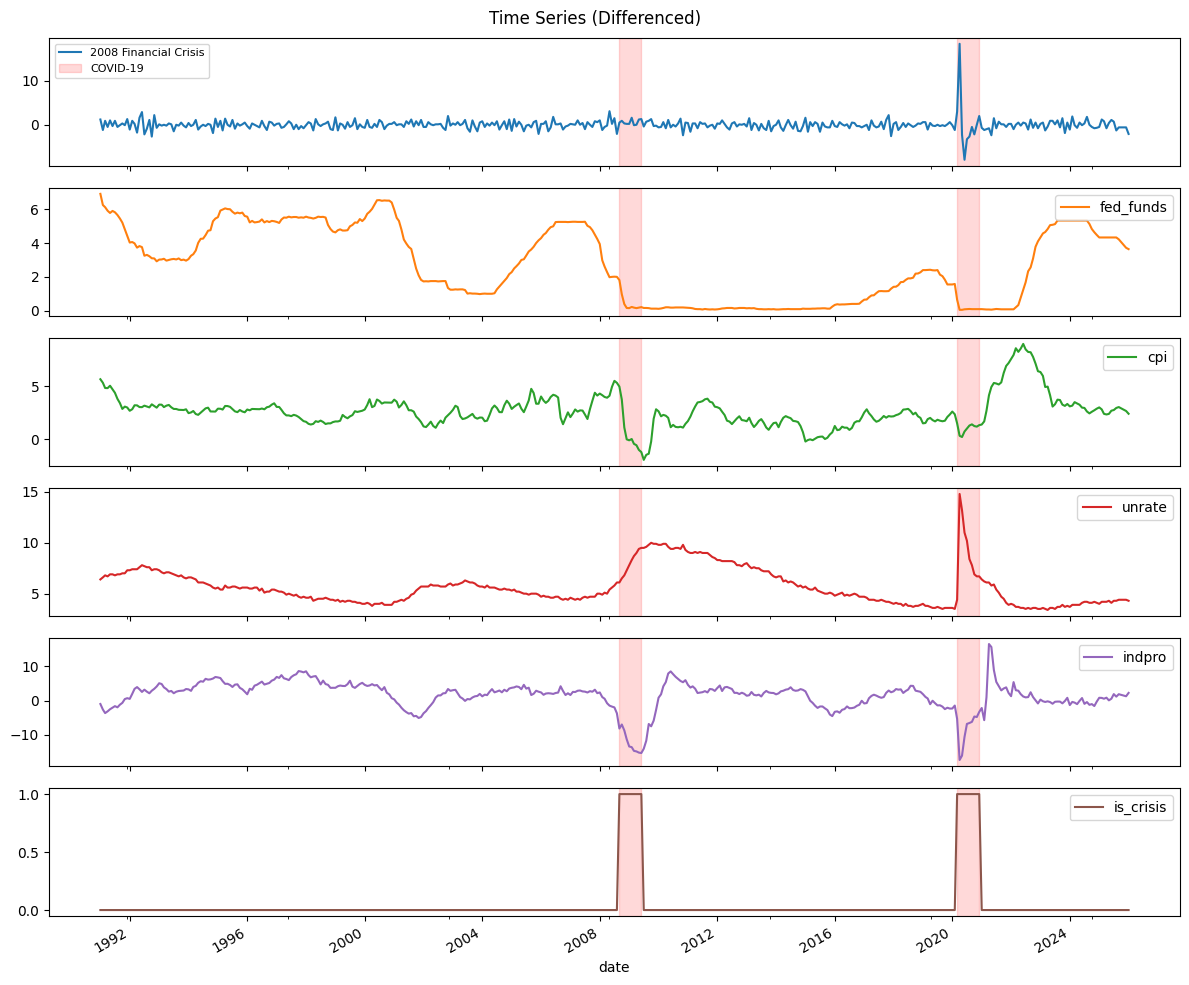

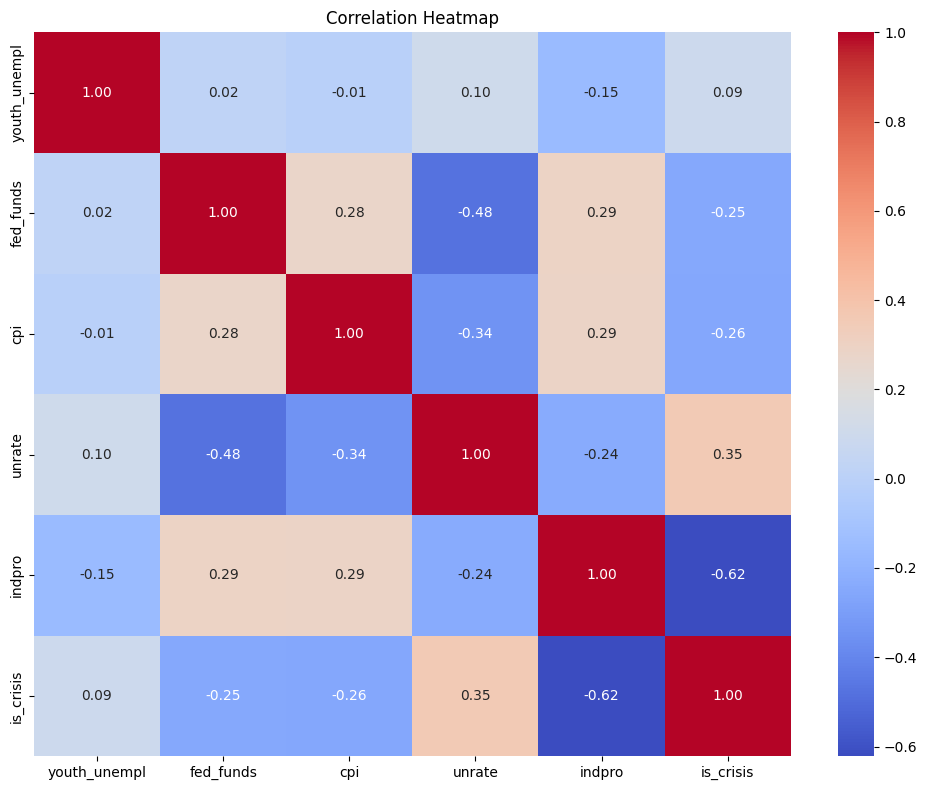

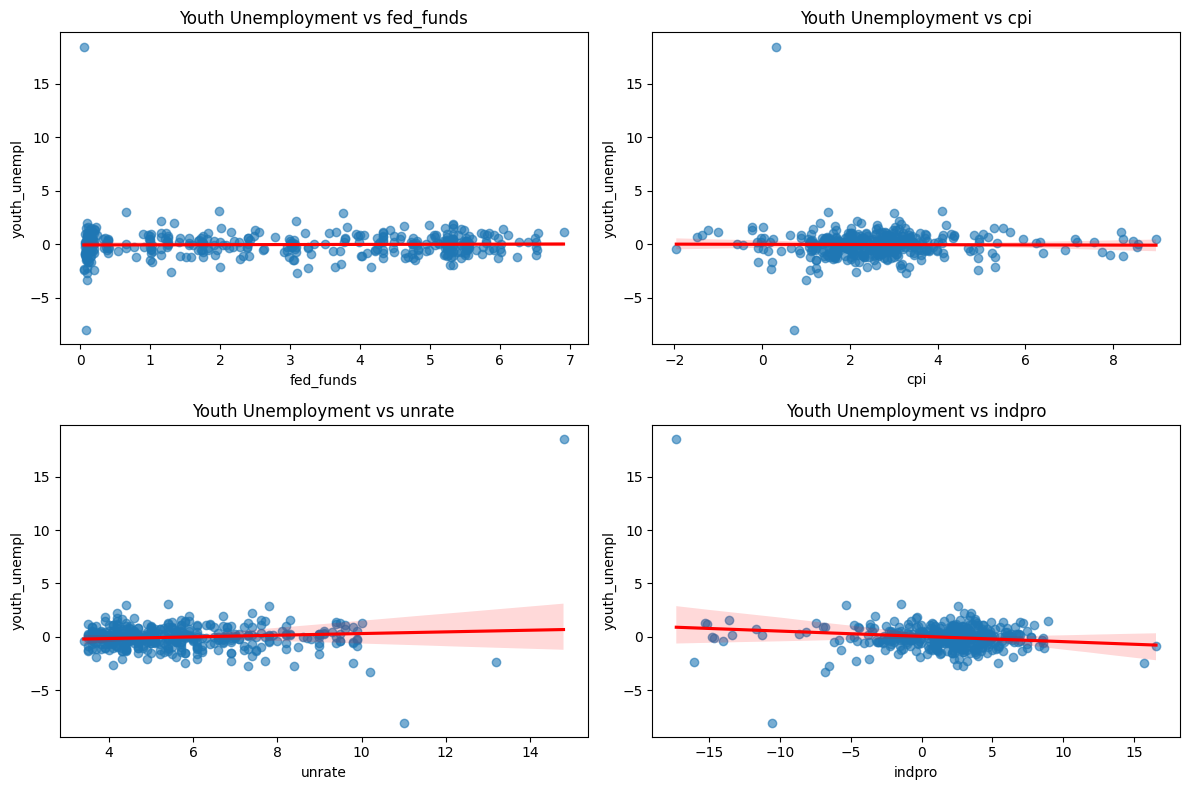


=== ADF TEST (p-value < 0.05 means stationary) ===
youth_unempl   : p-value = 2.1271774588401652e-20 - Satisfies
fed_funds      : p-value = 0.022037849419944487 - Satisfies
cpi            : p-value = 0.005271994369716186 - Satisfies
unrate         : p-value = 0.034018410218002934 - Satisfies
indpro         : p-value = 0.008905022341578195 - Satisfies
is_crisis      : p-value = 0.0020477305356555076 - Satisfies


In [113]:
# 1. Time series plot
axes = df_diff.plot(subplots=True, figsize=(12, 10), title="Time Series (Differenced)")

crisis_periods = [
    ("2008-09-01", "2009-06-01", "2008 Financial Crisis"),
    ("2020-03-01", "2020-12-01", "COVID-19"),
]

for ax in axes:
    for start, end, label in crisis_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='red', alpha=0.15, label=label)

axes[0].legend(["2008 Financial Crisis", "COVID-19"], fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_diff.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3. Scatter Plot
X_cols = ["fed_funds", "cpi", "unrate", "indpro"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), X_cols):
    sns.regplot(data=df_diff, x=col, y="youth_unempl", 
                ax=ax, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    ax.set_title(f"Youth Unemployment vs {col}")
plt.tight_layout()
plt.show()

# 4. ADF Test
print("\n=== ADF TEST (p-value < 0.05 means stationary) ===")

for col in df_diff.columns:
    result = stattools.adfuller(df_diff[col].dropna())
    status = "Satisfies" if result[1] < 0.05 else "Does not satisfy"
    print(f"{col:<15}: p-value = {result[1]} - {status}")


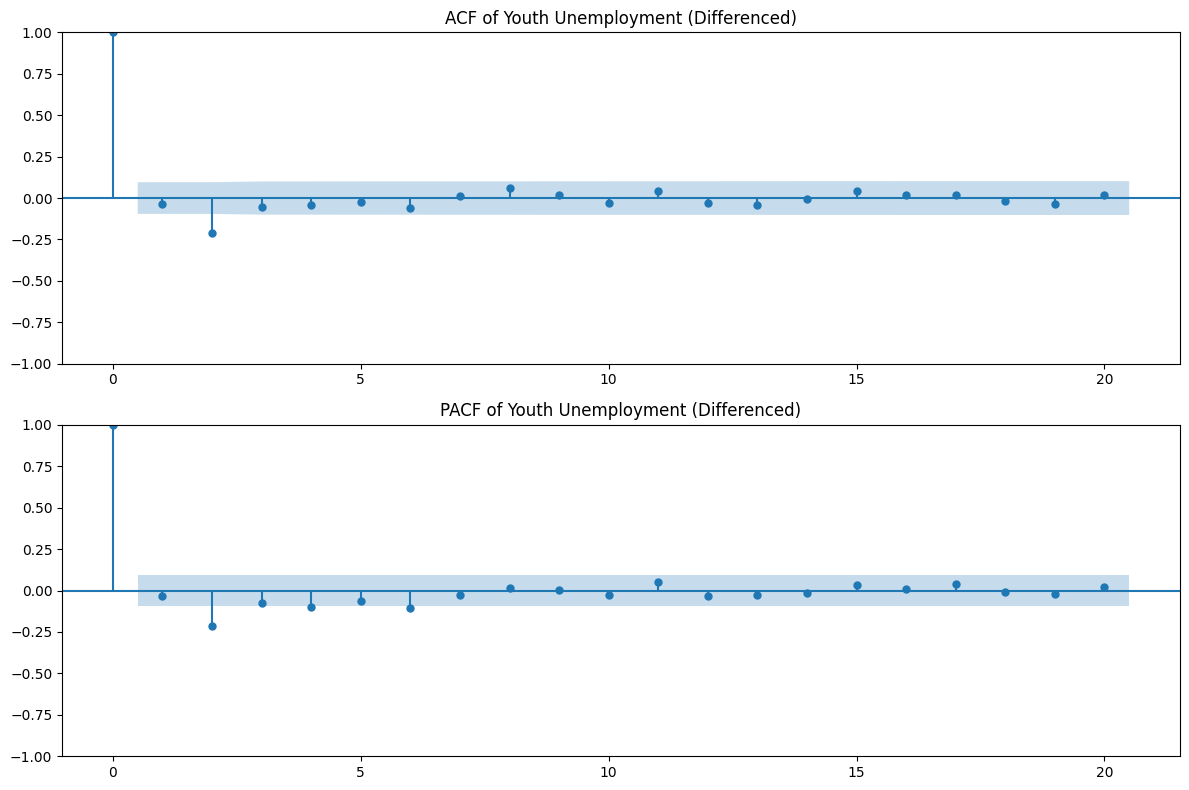

In [114]:
# To know Lag, we can use ACF and PACF plots, or information criteria 
# like AIC/BIC from ARIMA models. This helps determine how many past values 
# to include in a time series model.

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_diff["youth_unempl"].dropna(), lags=20, ax=axes[0])
plot_pacf(df_diff["youth_unempl"].dropna(), lags=20, ax=axes[1])
axes[0].set_title("ACF of Youth Unemployment (Differenced)")
axes[1].set_title("PACF of Youth Unemployment (Differenced)")
plt.tight_layout()
plt.show()